In [24]:
import platform
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from matplotlib import rc

# 가속 연산 디바이스(GPU/MPS) 자동 설정
# CUDA(NVIDIA) -> MPS(Mac 인텔/실리콘) -> CPU 순으로 사용 가능한 자원을 체크합니다.
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu"
)
print(f"현재 연산에 사용 중인 디바이스: {device}")

# matplotlib 한글 깨짐 방지 설정 
if platform.system() == 'Darwin':      # macOS 환경
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':   # Windows 환경
    rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

현재 연산에 사용 중인 디바이스: cpu


In [25]:
import torch.nn as nn
import torch.optim as optim

In [26]:
class AdvancedFashsionClassifier(nn.Module):    
    def __init__(self):
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(28 * 28, 64)
        self.relu = nn.ReLu()       
        self.dropout = nn.Dropout(p=0.01)
        self.linear2 = nn.Linear(64, 10)

In [27]:
raw_train_data = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=ToTensor()
)

In [28]:
train_size = 50000
val_size = 10000

train_data, val_data = random_split(
    raw_train_data, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("훈련 세트:", len(train_data))
print("검증 세트:", len(val_data))
print("테스트 세트:", len(test_data))

훈련 세트: 50000
검증 세트: 10000
테스트 세트: 10000


In [29]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [30]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1529, 0.2353, 0.2000,
           0.2235, 0.1961, 0.2157, 0.2078, 0.1961, 0.1922, 0.1647, 0.1725,
           0.1804, 0.1843, 0.2353, 0.0431],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.5216, 0.6196, 0.5922,
           0.7529, 0.7725, 0.8118, 0.7882, 

In [36]:
import torch.nn as nn
import torch.optim as optim 

class AdvancedFashionClassifier(nn.Module):

    # 사용할 층(layer)를 정의
    def __init__(self):
        super().__init__()

        # (28, 28) -> 특성은 1차원으로 변경 (784,)
        # nn.Flatten() -> 2차원 텐서 -> 1차원 텐서 - 입력층
        self.flatten = nn.Flatten()

        # 은닉층 (784 -> 128)
        self.hidden_layer = nn.Linear(784, 128)

        # 활성화 함수(ReLU)
        self.relu = nn.ReLU()

        # Dropout - 0~1, 0.1~0.5
        self.dropout = nn.Dropout(p=0.2)

        # 출력층 128 -> 10
        self.output_layer = nn.Linear(128, 10)

    # 순전파(Feed Forward)
    def forward(self, x):
        out = self.flatten(x) # 28 X 27 -> 784 # 입력층 처리
        out = self.hidden_layer(out) # 784 -> 128 # 은닉층 처리
        out = self.relu(out) # 활성화 함수 통과(선형적 -> 비선형적)
        out = self.dropout(out) # 훈련시에만 피요, 과대적합 방지 (128,)
        out = self.output_layer(out) # 출력층 128 -> 10

        return out

In [37]:
model = AdvancedFashionClassifier().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"학습 가능한 총 모델 파라미터 갯수: {total_params:,}개")

학습 가능한 총 모델 파라미터 갯수: 101,770개


In [39]:
criterion = nn.CrossEntropyLoss()

# 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=0.005)

In [40]:
epochs = 20 # 최대 에포크
patience = 3 # 검증 로스가 더이상 떨어지지 않는 횟수, 3회 이상이면 학습 종료(조기종료)
patience_count = 0
best_val_loss = float('inf')

train_losses = []
val_losses = []

for epoch in range(epochs):
    running_loss = 0.0 #한 에포크(각 배치의 모든 손실)의 손실
    model.train() # 학습 모드 (학습에 필요한 것들 활성 - 예) Dropout )

    for images, labels in train_loader: # 미니배치(32개씩)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 이전 그래디언트(기울기)를 초기화

        # 순방향 예측 
        outputs = model(images)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 오차 역전파 수행  - 그래디언트(기울기)
        loss.backward()

        # 옵티마이저를 통한 가중치 업데이트
        optimizer.step()

        running_loss += loss.item() # 배치마다의 로스를 기록(1에포크)

    epoch_loss = running_loss / len(train_loader) # 1에포크 로스(배치 로스의 평균)
    train_losses.append(epoch_loss)

    # 검증 모드
    model.eval() # 평가시에는 학습시에만 필요한 부분이 배제, Dropout 배제
    val_loss = 0.0 

    with torch.no_grad(): # 검증시에는 그래디언트를 구하지 않는다. 학습 관련 연산을 하지 않음
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            # 검증 예측(순전파)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | 훈련 loss: {epoch_loss:.4f} | 검증 loss: {val_loss:.4f}")

    # 조기 종료 
    if epoch_val_loss < best_val_loss:
        # 기존 검증 로스보다 개선이 되었다!
        best_val_loss = epoch_val_loss
        patience_count = 0

        # 손실이 개선된 모델을 저장
        torch.save(model.state_dict(), "best_fashion_model.pth")

    else: # 기존 검증 로스보다 개선이 안되었다!
        patience_count += 1
        print(f"== 검증 손실 미개선: {patience_count}/{patience} ==")

        # patience 한계를 초과하면 학습을 중단(조기종료)
        if patience_count >= patience:
            print(f"조기 종료:{epoch+1}에포크에서 학습 종료...")
            break

Epoch 1/20 | 훈련 loss: 0.5689 | 검증 loss: 143.2846
Epoch 2/20 | 훈련 loss: 0.4705 | 검증 loss: 126.0593
Epoch 3/20 | 훈련 loss: 0.4468 | 검증 loss: 141.8947
== 검증 손실 미개선: 1/3 ==
Epoch 4/20 | 훈련 loss: 0.4249 | 검증 loss: 119.9450
Epoch 5/20 | 훈련 loss: 0.4135 | 검증 loss: 130.6899
== 검증 손실 미개선: 1/3 ==
Epoch 6/20 | 훈련 loss: 0.4016 | 검증 loss: 124.2146
== 검증 손실 미개선: 2/3 ==
Epoch 7/20 | 훈련 loss: 0.3910 | 검증 loss: 120.5368
== 검증 손실 미개선: 3/3 ==
조기 종료:7에포크에서 학습 종료...


In [41]:
model.load_state_dict(torch.load("best_fashion_model.pth"))
model.to(device)

# 테스트 셋으로 평가
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        print("predicted:", predicted)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total * 100
print(f"테스트 세트 정확도: {test_accuracy:.4f}%")

predicted: tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4, 1, 2, 2, 8, 0, 2, 5, 7, 7,
        1, 2, 6, 0, 9, 4, 8, 8])
predicted: tensor([3, 3, 8, 0, 7, 5, 7, 9, 0, 1, 6, 7, 6, 7, 2, 1, 2, 2, 4, 2, 5, 8, 2, 2,
        8, 4, 8, 0, 7, 7, 8, 5])
predicted: tensor([1, 1, 3, 4, 7, 8, 7, 0, 6, 6, 2, 3, 1, 2, 8, 4, 1, 8, 5, 9, 5, 0, 3, 2,
        0, 2, 5, 3, 6, 7, 1, 8])
predicted: tensor([0, 1, 4, 2, 3, 6, 7, 6, 7, 8, 5, 7, 9, 4, 2, 5, 7, 0, 5, 2, 8, 2, 7, 8,
        0, 0, 9, 9, 3, 0, 8, 4])
predicted: tensor([1, 5, 4, 1, 9, 1, 8, 4, 2, 1, 2, 5, 1, 6, 0, 0, 1, 6, 1, 3, 2, 2, 6, 2,
        1, 3, 5, 0, 4, 7, 9, 3])
predicted: tensor([7, 2, 3, 9, 0, 9, 4, 7, 4, 2, 6, 5, 2, 1, 2, 1, 3, 0, 9, 1, 0, 9, 0, 6,
        7, 9, 9, 4, 4, 7, 1, 2])
predicted: tensor([1, 6, 3, 2, 8, 4, 6, 1, 1, 0, 2, 9, 2, 4, 0, 7, 9, 8, 4, 1, 8, 4, 1, 3,
        1, 6, 7, 4, 8, 5, 2, 0])
predicted: tensor([7, 7, 6, 2, 7, 0, 7, 8, 9, 2, 9, 0, 5, 1, 4, 2, 5, 6, 9, 2, 2, 8, 6, 2,
        2, 4, 9, 7, 6, 5, 5, 4])
predicte

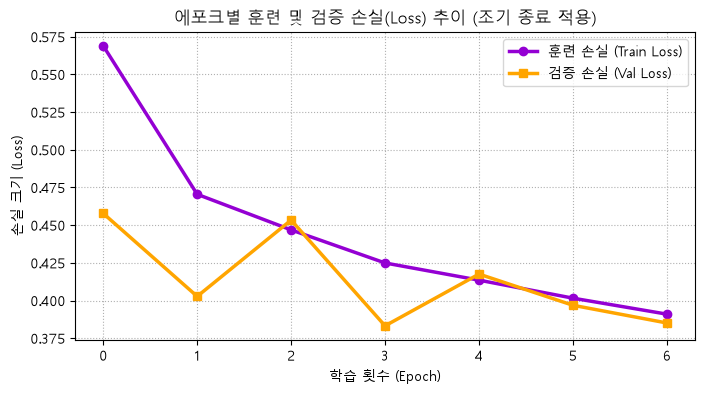

In [42]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o', color='darkviolet', linewidth=2.5, label='훈련 손실 (Train Loss)')
plt.plot(val_losses, marker='s', color='orange', linewidth=2.5, label='검증 손실 (Val Loss)')
plt.title("에포크별 훈련 및 검증 손실(Loss) 추이 (조기 종료 적용)")
plt.xlabel("학습 횟수 (Epoch)")
plt.ylabel("손실 크기 (Loss)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()


In [43]:
import torch
import torch.nn as nn

class FashionMNISTModel(nn.Module):
    def __init__(self):
        super(FashionMNISTModel, self).__init__()
        self.flatten = nn.Flatten()                # 28x28 이미지를 784 벡터로 평탄화
        self.fc1 = nn.Linear(784, 64)               # 입력 784 -> 은닉 64
        self.relu = nn.ReLU()                       # 비선형 활성화 함수
        self.fc2 = nn.Linear(64, 10)                # 은닉 64 -> 출력 10 (카테고리 수)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = FashionMNISTModel()

# 옵티마이저 설정: SGD, 학습률 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# 손실 함수 (분류 문제이므로 일반적으로 함께 사용)
criterion = nn.CrossEntropyLoss()

In [46]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1529, 0.2353, 0.2000,
           0.2235, 0.1961, 0.2157, 0.2078, 0.1961, 0.1922, 0.1647, 0.1725,
           0.1804, 0.1843, 0.2353, 0.0431],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.5216, 0.6196, 0.5922,
           0.7529, 0.7725, 0.8118, 0.7882, 